# Rosa's Pizza: finding the best delivery promise
**MMGMT 722 · Assignment 1**

## Summary
For Far West on Friday/Saturday evening, **36.7%**
of simulated orders miss today's 45-minute promise, although the average delivery
time is **42.9 minutes**.
Using the supplied costs and seed 1, **55 minutes** is the best
tested promise in the 20–90 minute grid. Estimated four-week net profit is
**\$1,212.40**, compared with **\$-127.40** at 45 minutes.

The analysis below follows Parts I(a–e) and II(a–b). Part III links and the AI-use
appendix are at the end. Results are simulated, not records of real deliveries.

## Context, method, and assumptions
Rosa must balance demand against refunds and the future profit lost after late
deliveries. A shorter promise attracts more orders but also increases congestion.
Staffing is fixed; changing staffing, delivery zones, and pricing is outside this assignment.

- Source: the supplied *Assignment 1 – Finding the Best Delivery Promise for Rosa's Pizza*.
- Background: supplied *1. Introduction to DA*, especially the contrast between means and late-delivery tails.
- Data: the professor's `rosa-starter` package, imported without changes.
- One array entry represents one order's delivery time in minutes; each array covers four weeks in one pair.
- Lateness is strictly `delivery time > promise`; exactly on the promise is on time.
- Default seed is 1 for reproducibility. The same seed is reused for each pair and
  candidate; samples therefore share random streams. This is a controlled comparison,
  not an independence assumption or a confidence interval.
- Pooled measures weight each **order**, not each zone/time block, equally.
- Profit is a four-week accounting estimate with future churn loss charged to
  the late orders in that period. It is not a pure four-week cash-flow forecast.

## Setup
In VS Code, select the project's `.venv` Python kernel. This notebook also runs
as a single file in Colab or local Jupyter: it includes the same function definitions
as the app's shared module and does not require that module to be beside it.

The next cell installs dependencies only if they are missing. In a fresh notebook
environment, the professor's installation command is
`%pip install git+https://github.com/zhouy185/rosa-starter.git`.

In [1]:
import importlib.util
import subprocess
import sys

packages = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib',
            'starter': 'git+https://github.com/zhouy185/rosa-starter.git'}
missing = [package for module, package in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])

In [2]:
import math
from numbers import Real
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from starter import ZONES, TIME_BLOCKS, COSTS, PROMISE, delivery_times

SEED = 1
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 120})
pd.options.display.float_format = '{:,.2f}'.format
print('Zones:', ZONES)
print('Time blocks:', TIME_BLOCKS)
print('Costs:', COSTS)
print('Package versions:', {name: version(name) for name in ['rosa-starter', 'numpy', 'pandas']})

Zones: ['Central', 'North', 'Far West']
Time blocks: ['Lunch', 'Weekday eve', 'Fri/Sat eve', 'Other']
Costs: {'refund': 10.0, 'churn_orders': 1.8, 'margin': 9.0}
Package versions: {'rosa-starter': '0.1.0', 'numpy': '2.5.3', 'pandas': '3.0.6'}


### First example: what the array means
`delivery_times` is a function: we supply a zone, time block, promise, and seed.
`len(times)` counts orders. `times.mean()` averages the individual times, and
`round(..., 1)` changes only the displayed precision. We retain full precision
for calculation and comparison.

In [3]:
times = delivery_times('Far West', 'Fri/Sat eve', PROMISE, seed=SEED)
print(len(times), 'orders; average delivery time', round(times.mean(), 1), 'minutes')
print('First five order delivery times:', times[:5])

210 orders; average delivery time 42.9 minutes
First five order delivery times: [46.6 53.7 46.4 28.4 55.1]


## Part I(a): percentage of late orders
First choose the applicable zones and blocks. A `for` loop visits each pair;
`np.concatenate` pools individual orders into one array. This prevents an
unweighted average of group percentages from giving small groups too much weight.

`times > promise` compares every order with the promise and creates True/False
values. `np.count_nonzero` counts True values (late orders).

**Late percentage = 100 × total late orders / total orders.**

In [4]:
def positive_number(value, name):
    """Reject nonnumeric, infinite, or nonpositive inputs."""
    if isinstance(value, bool) or not isinstance(value, Real):
        raise ValueError(f"{name} must be a positive finite number.")
    if not math.isfinite(value) or value <= 0:
        raise ValueError(f"{name} must be a positive finite number.")
    return float(value)

def validate_costs(costs):
    """Return validated refund, future-order loss, and margin assumptions."""
    checked = {}
    for key in ("refund", "churn_orders", "margin"):
        if key not in costs:
            raise ValueError(f"Missing cost assumption: {key}.")
        value = costs[key]
        if isinstance(value, bool) or not isinstance(value, Real):
            raise ValueError(f"{key} must be a finite nonnegative number.")
        if not math.isfinite(value) or value < 0:
            raise ValueError(f"{key} must be a finite nonnegative number.")
        checked[key] = float(value)
    return checked

def selected_times(zone, time_block, promise, seed=SEED):
    """Pool individual orders across the requested selections."""
    positive_number(promise, "Promise")
    if zone != "all" and zone not in ZONES:
        raise ValueError(f"Zone must be one of {ZONES} or 'all'.")
    if time_block != "all" and time_block not in TIME_BLOCKS:
        raise ValueError(f"Time block must be one of {TIME_BLOCKS} or 'all'.")
    zones = ZONES if zone == "all" else [zone]
    blocks = TIME_BLOCKS if time_block == "all" else [time_block]
    arrays = []
    for selected_zone in zones:
        for selected_block in blocks:
            times = delivery_times(selected_zone, selected_block, promise, seed=seed)
            arrays.append(times)
    return np.concatenate(arrays)

def late_percentage(zone, time_block, promise, seed=SEED):
    """Percentage of individual orders strictly later than the promise."""
    times = selected_times(zone, time_block, promise, seed)
    if len(times) == 0:
        raise ValueError("No orders were simulated; a late percentage is undefined.")
    late_orders = np.count_nonzero(times > promise)
    return 100 * late_orders / len(times)

In [5]:
examples = [('Far West', 'Fri/Sat eve'), ('all', 'Lunch'),
            ('North', 'all'), ('all', 'all')]
late_examples = pd.DataFrame([
    {'Zone': zone, 'Time block': block, 'Late (%)': late_percentage(zone, block, PROMISE)}
    for zone, block in examples
])
display(late_examples.round(2))

,Zone,Time block,Late (%)
0,Far West,Fri/Sat eve,36.67
1,all,Lunch,3.33
2,North,all,6.80
3,all,all,8.29


## Part I(b): rank all pairs by late rate
Each row below is one of the three zones × four time blocks. `sort_values`
orders the rows from the highest late percentage to the lowest. Exact ties are
ordered by zone and time-block name for consistent presentation.

In [6]:
def delivery_rankings(promise=PROMISE, seed=SEED):
    """Describe all 12 pairs using one reproducible sample per pair."""
    rows = []
    for zone in ZONES:
        for time_block in TIME_BLOCKS:
            times = selected_times(zone, time_block, promise, seed)
            if len(times) == 0:
                raise ValueError("No orders were simulated for a selected pair.")
            rows.append({
                "zone": zone,
                "time_block": time_block,
                "orders": len(times),
                "late_percentage": 100 * np.count_nonzero(times > promise) / len(times),
                "average_minutes": float(times.mean()),
            })
    return pd.DataFrame(rows)

In [7]:
ranking_data = delivery_rankings(PROMISE)
late_ranking = ranking_data.sort_values(
    ['late_percentage', 'zone', 'time_block'], ascending=[False, True, True]
).reset_index(drop=True)
display(late_ranking.rename(columns={
    'zone': 'Zone', 'time_block': 'Time block', 'orders': 'Orders',
    'late_percentage': 'Late (%)', 'average_minutes': 'Average (min)'
}).round(2))

,Zone,Time block,Orders,Late (%),Average (min)
0,Far West,Fri/Sat eve,210,36.67,42.92
1,North,Fri/Sat eve,150,16.67,36.77
2,Far West,Weekday eve,170,11.18,35.04
3,Central,Fri/Sat eve,190,6.84,32.13
4,North,Weekday eve,250,6.00,31.38
5,Far West,Other,192,4.69,30.04
6,Central,Weekday eve,330,4.24,29.03
7,North,Lunch,190,3.68,28.67
8,Central,Lunch,260,3.46,26.80
9,Central,Other,190,2.63,26.04


## Part I(c): average delivery time
Pool the same selected orders, then calculate the mean. This gives each order
equal weight. If no orders are simulated, the function raises a clear error
rather than reporting an undefined rate or average as zero.

In [8]:
def average_delivery_time(zone, time_block, promise, seed=SEED):
    """Mean minutes per order, weighted naturally by pooling orders."""
    times = selected_times(zone, time_block, promise, seed)
    if len(times) == 0:
        raise ValueError("No orders were simulated; an average is undefined.")
    return float(times.mean())

In [9]:
average_examples = pd.DataFrame([
    {'Zone': zone, 'Time block': block,
     'Average delivery time (min)': average_delivery_time(zone, block, PROMISE)}
    for zone, block in examples
])
display(average_examples.round(2))

,Zone,Time block,Average delivery time (min)
0,Far West,Fri/Sat eve,42.92
1,all,Lunch,28.22
2,North,all,30.98
3,all,all,31.19


## Part I(d): rank all pairs by average delivery time
Use the same simulated observations as the late ranking so differences in the
rankings reflect the measures rather than fresh simulation draws.

,Zone,Time block,Orders,Late (%),Average (min)
0,Far West,Fri/Sat eve,210,36.67,42.92
1,North,Fri/Sat eve,150,16.67,36.77
2,Far West,Weekday eve,170,11.18,35.04
3,Central,Fri/Sat eve,190,6.84,32.13
4,North,Weekday eve,250,6.00,31.38
5,Far West,Lunch,120,2.50,30.58
6,Far West,Other,192,4.69,30.04
7,Central,Weekday eve,330,4.24,29.03
8,North,Lunch,190,3.68,28.67
9,North,Other,160,2.50,27.66


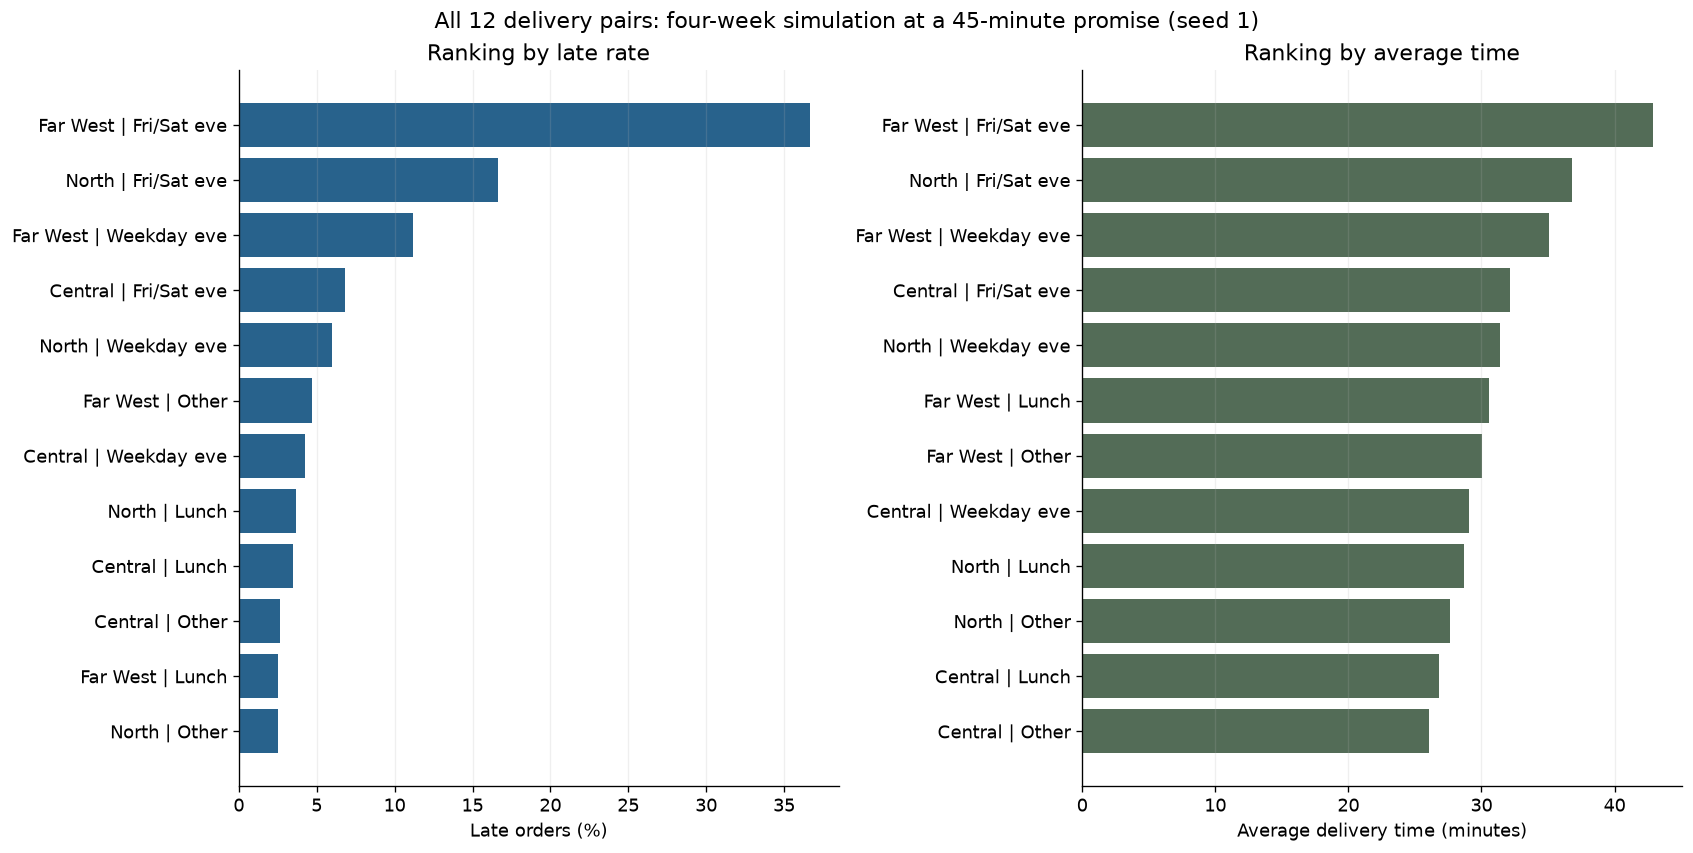

In [10]:
average_ranking = ranking_data.sort_values(
    ['average_minutes', 'zone', 'time_block'], ascending=[False, True, True]
).reset_index(drop=True)
display(average_ranking.rename(columns={
    'zone': 'Zone', 'time_block': 'Time block', 'orders': 'Orders',
    'late_percentage': 'Late (%)', 'average_minutes': 'Average (min)'
}).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 7), layout='constrained')
for ax, table, metric, label, color in [
    (axes[0], late_ranking, 'late_percentage', 'Late orders (%)', '#28628C'),
    (axes[1], average_ranking, 'average_minutes', 'Average delivery time (minutes)', '#536C57')
]:
    labels = table['zone'] + ' | ' + table['time_block']
    ax.barh(labels, table[metric], color=color)
    ax.invert_yaxis()
    ax.set_xlim(left=0)
    ax.set_xlabel(label)
    ax.set_title('Ranking by ' + ('late rate' if metric == 'late_percentage' else 'average time'))
    ax.grid(axis='x', alpha=0.2)
fig.suptitle('All 12 delivery pairs: four-week simulation at a 45-minute promise (seed 1)')
plt.show()

## Part I(e): which measure better supports Rosa's decision?
The **late percentage** is more directly relevant because refunds and lost future
margin are triggered by crossing the promise. Mean time alone does not describe
that costly tail. For a complete financial decision, we also need order volumes
and costs, as addressed in Part II.

In [11]:
worst = late_ranking.iloc[0]
far_lunch = ranking_data.query("zone == 'Far West' and time_block == 'Lunch'").iloc[0]
central_lunch = ranking_data.query("zone == 'Central' and time_block == 'Lunch'").iloc[0]
display(Markdown(
    f"**Evidence:** {worst.zone} / {worst.time_block} has the highest late rate "
    f"({worst.late_percentage:.1f}%) and average time ({worst.average_minutes:.1f} min). "
    "Its mean remains below 45 minutes, but more than one third of orders are late. "
    f"Far West / Lunch averages {far_lunch.average_minutes:.1f} minutes with "
    f"{far_lunch.late_percentage:.2f}% late, whereas Central / Lunch averages "
    f"{central_lunch.average_minutes:.1f} minutes with {central_lunch.late_percentage:.2f}% late. "
    "Thus, a higher average does not necessarily mean a higher late rate in a finite sample. "
    "Both rankings identify weekend evenings as important, but late rates more directly "
    "describe failure to meet the customer promise."
))

**Evidence:** Far West / Fri/Sat eve has the highest late rate (36.7%) and average time (42.9 min). Its mean remains below 45 minutes, but more than one third of orders are late. Far West / Lunch averages 30.6 minutes with 2.50% late, whereas Central / Lunch averages 26.8 minutes with 3.46% late. Thus, a higher average does not necessarily mean a higher late rate in a finite sample. Both rankings identify weekend evenings as important, but late rates more directly describe failure to meet the customer promise.

## Part II(a): cost per late order
Refund is an immediate cost. Churn is measured in **future orders lost**, not a
percentage of customers. Multiply those lost orders by margin to express the
future loss in dollars, then add the refund.

In [12]:
def cost_per_late_order(costs=COSTS):
    """Refund plus the contribution margin lost on future orders."""
    checked = validate_costs(costs)
    return checked["refund"] + checked["churn_orders"] * checked["margin"]

In [13]:
late_cost = cost_per_late_order(COSTS)
print(f"Cost per late order = ${COSTS['refund']:.2f} + {COSTS['churn_orders']:.1f} × ${COSTS['margin']:.2f} = ${late_cost:.2f}")

Cost per late order = $10.00 + 1.8 × $9.00 = $26.20


## Part II(b): search for the most profitable promise
### Choosing the range
Begin with **20–90 minutes inclusive, in five-minute steps**. This covers promises
well below and above today's 45 minutes and the observed mean times. It is a
deliberately broad starting range, not a range chosen to force the slide's answer.
For each pair, extend the relevant boundary by 25 minutes if its winner is at an
endpoint. Stop at an interior winner or the practical guardrails of 5 and 180 minutes;
flag a guardrail winner as unresolved boundary evidence.

An interior winner suggests the grid brackets the useful trade-off, but does
not prove a global optimum or identify a best promise between grid values.

### Profit calculation and reusable interface
For **every candidate**, call the simulator again: demand and delivery congestion
change with the promise. Do not reuse a fixed 45-minute order sample.

`best_promise(zone, time_block, promises, costs, seed=1)` returns a dictionary with
`promise`, `net_profit`, and `results` (a table covering every tested candidate).
Exact profit ties favor the shorter promise; selection uses unrounded values.

**Net profit = orders × margin − late orders × (refund + churn orders × margin).**

In [14]:
def evaluate_promises(zone, time_block, promises, costs=COSTS, seed=SEED):
    """Simulate demand and delivery times anew for every tested promise."""
    if zone not in ZONES or time_block not in TIME_BLOCKS:
        raise ValueError("Choose one valid zone and one valid time block.")
    candidates = list(promises)
    if not candidates:
        raise ValueError("Provide at least one candidate promise.")
    candidates = sorted({positive_number(p, "Promise") for p in candidates})
    checked = validate_costs(costs)
    late_cost = cost_per_late_order(checked)
    rows = []
    for promise in candidates:
        times = delivery_times(zone, time_block, promise, seed=seed)
        orders = len(times)
        late_orders = int(np.count_nonzero(times > promise))
        gross_profit = orders * checked["margin"]
        late_cost_total = late_orders * late_cost
        rows.append({
            "promise": promise,
            "orders": orders,
            "late_orders": late_orders,
            "late_percentage": 100 * late_orders / orders if orders else np.nan,
            "gross_profit": gross_profit,
            "late_cost": late_cost_total,
            "net_profit": gross_profit - late_cost_total,
        })
    results = pd.DataFrame(rows)
    if results["orders"].sum() == 0:
        raise ValueError("No orders were simulated for any candidate. Try shorter promises.")
    return results

def best_promise(zone, time_block, promises, costs=COSTS, seed=SEED):
    """Return the winning minutes, four-week net profit, and candidate table.

    Sorting profit descending and promise ascending resolves exact ties in
    favor of the shorter promise. Comparisons use unrounded dollar values.
    """
    results = evaluate_promises(zone, time_block, promises, costs, seed)
    winner = results.sort_values(
        ["net_profit", "promise"], ascending=[False, True]
    ).iloc[0]
    return {
        "promise": float(winner["promise"]),
        "net_profit": float(winner["net_profit"]),
        "results": results,
    }

def promise_range(minimum, maximum):
    """Inclusive five-minute grid for the app and notebook."""
    positive_number(minimum, "Minimum promise")
    positive_number(maximum, "Maximum promise")
    if minimum > maximum:
        raise ValueError("Minimum promise must not exceed maximum promise.")
    if minimum % 5 != 0 or maximum % 5 != 0:
        raise ValueError("Range endpoints must be multiples of five minutes.")
    return list(range(int(minimum), int(maximum) + 1, 5))

def search_with_expansion(zone, time_block, costs=COSTS, seed=SEED):
    """Start at 20-90; extend boundary maxima in 25-minute increments.

    Guardrails are 5 and 180 minutes. A guardrail winner is explicitly flagged
    rather than described as an interior optimum.
    """
    minimum, maximum = 20, 90
    while True:
        result = best_promise(zone, time_block, promise_range(minimum, maximum), costs, seed)
        extend_low = result["promise"] == minimum and minimum > 5
        extend_high = result["promise"] == maximum and maximum < 180
        if not extend_low and not extend_high:
            result["minimum"] = minimum
            result["maximum"] = maximum
            result["boundary_winner"] = result["promise"] in (minimum, maximum)
            return result
        if extend_low:
            minimum = max(5, minimum - 25)
        if extend_high:
            maximum = min(180, maximum + 25)

In [15]:
detail = search_with_expansion('Far West', 'Fri/Sat eve', COSTS)
candidate_results = detail['results']
current = best_promise('Far West', 'Fri/Sat eve', [PROMISE], COSTS)
print(f"Range checked: {detail['minimum']}–{detail['maximum']} minutes, step 5")
print(f"Recommended promise: {detail['promise']:.0f} minutes")
print(f"Estimated four-week net profit: ${detail['net_profit']:,.2f}")
print(f"Current 45-minute promise: ${current['net_profit']:,.2f}")
print(f"Estimated improvement: ${detail['net_profit'] - current['net_profit']:,.2f}")
display(candidate_results.rename(columns={
    'promise': 'Promise (min)', 'orders': 'Orders', 'late_orders': 'Late orders',
    'late_percentage': 'Late (%)', 'gross_profit': 'Order margin ($)',
    'late_cost': 'Late costs ($)', 'net_profit': 'Net profit ($)'
}).round(2))

Range checked: 20–90 minutes, step 5
Recommended promise: 55 minutes
Estimated four-week net profit: $1,212.40
Current 45-minute promise: $-127.40
Estimated improvement: $1,339.80


,Promise (min),Orders,Late orders,Late (%),Order margin ($),Late costs ($),Net profit ($)
0,20.00,241,239,99.17,"2,169.00","6,261.80","-4,092.80"
1,25.00,239,233,97.49,"2,151.00","6,104.60","-3,953.60"
2,30.00,237,218,91.98,"2,133.00","5,711.60","-3,578.60"
3,35.00,232,179,77.16,"2,088.00","4,689.80","-2,601.80"
4,40.00,224,133,59.38,"2,016.00","3,484.60","-1,468.60"
5,45.00,210,77,36.67,"1,890.00","2,017.40",-127.40
6,50.00,188,33,17.55,"1,692.00",864.60,827.40
7,55.00,158,8,5.06,"1,422.00",209.60,"1,212.40"
8,60.00,121,2,1.65,"1,089.00",52.40,"1,036.60"
9,65.00,84,0,0.00,756.00,0.00,756.00


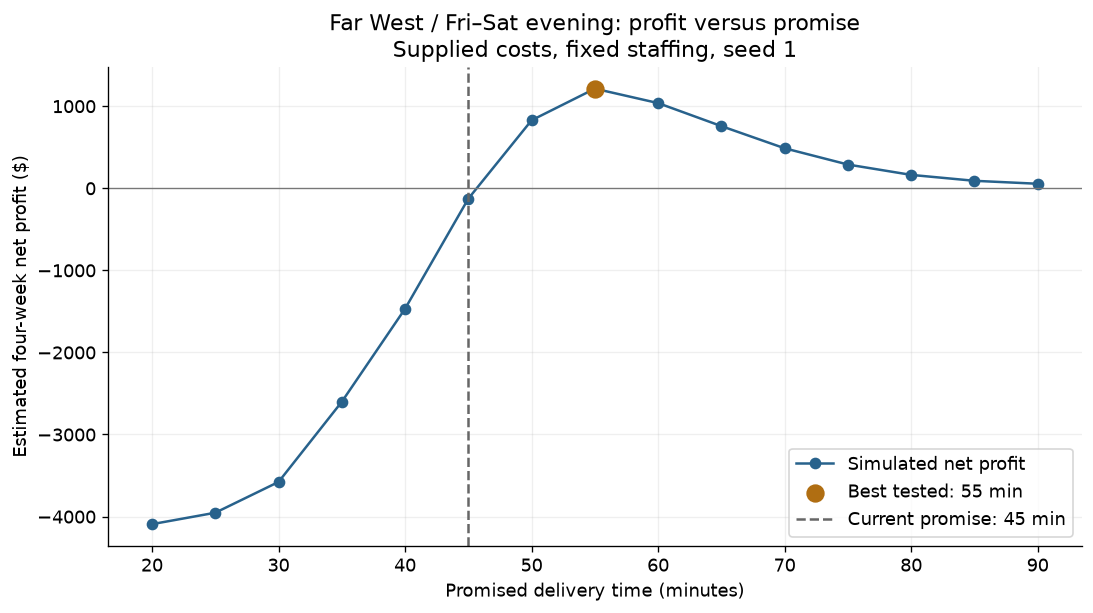

In [16]:
fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
ax.plot(candidate_results['promise'], candidate_results['net_profit'],
        marker='o', color='#28628C', label='Simulated net profit')
ax.scatter([detail['promise']], [detail['net_profit']], color='#B06E12', s=100,
           zorder=3, label=f"Best tested: {detail['promise']:.0f} min")
ax.axvline(PROMISE, color='#666666', linestyle='--', label='Current promise: 45 min')
ax.axhline(0, color='#777777', linewidth=0.8)
ax.set_xlabel('Promised delivery time (minutes)')
ax.set_ylabel('Estimated four-week net profit ($)')
ax.set_title('Far West / Fri–Sat evening: profit versus promise\nSupplied costs, fixed staffing, seed 1')
ax.grid(alpha=0.2)
ax.legend(loc='lower right')
plt.show()

### Recommendations across all pairs
The table compares each pair's best tested option with its current 45-minute
promise using the same costs and seed. These are pair-level recommendations,
not a model of system-wide staffing changes or cross-zone operational effects.

In [17]:
recommendations = []
for zone in ZONES:
    for block in TIME_BLOCKS:
        result = search_with_expansion(zone, block, COSTS)
        baseline = best_promise(zone, block, [PROMISE], COSTS)['net_profit']
        recommendations.append({
            'Zone': zone, 'Time block': block, 'Best promise (min)': result['promise'],
            'Net profit ($)': result['net_profit'], 'At 45 min ($)': baseline,
            'Improvement ($)': result['net_profit'] - baseline,
            'Range (min)': f"{result['minimum']}–{result['maximum']}",
            'Boundary winner': result['boundary_winner'],
        })
recommendation_table = pd.DataFrame(recommendations)
display(recommendation_table.round(2))
display(Markdown(
    f"All {len(recommendation_table)} pairs have interior winners in the initial 20–90-minute grid; "
    "no range expansion was needed for seed 1. This supports using that range for the main comparison."
    if not recommendation_table['Boundary winner'].any() and (recommendation_table['Range (min)'] == '20–90').all()
    else "At least one pair required expansion or has a boundary winner; review the range columns before recommending it."
))

,Zone,Time block,Best promise (min),Net profit ($),At 45 min ($),Improvement ($),Range (min),Boundary winner
0,Central,Lunch,45.00,"2,104.20","2,104.20",0.00,20–90,False
1,Central,Weekday eve,45.00,"2,603.20","2,603.20",0.00,20–90,False
2,Central,Fri/Sat eve,50.00,"1,399.00","1,369.40",29.60,20–90,False
3,Central,Other,45.00,"1,579.00","1,579.00",0.00,20–90,False
4,North,Lunch,45.00,"1,526.60","1,526.60",0.00,20–90,False
5,North,Weekday eve,45.00,"1,857.00","1,857.00",0.00,20–90,False
6,North,Fri/Sat eve,50.00,996.40,695.00,301.40,20–90,False
7,North,Other,45.00,"1,335.20","1,335.20",0.00,20–90,False
8,Far West,Lunch,45.00,"1,001.40","1,001.40",0.00,20–90,False
9,Far West,Weekday eve,50.00,"1,210.80","1,032.20",178.60,20–90,False


All 12 pairs have interior winners in the initial 20–90-minute grid; no range expansion was needed for seed 1. This supports using that range for the main comparison.

### Sensitivity to simulation randomness: seeds 1–10
Repeat the Far West/weekend search across ten seeds. This is a small sensitivity
check, not a statistical confidence interval. Compare the two leading promises
within each seed as well as the per-seed winners.

In [18]:
seed_rows = []
for seed in range(1, 11):
    result = search_with_expansion('Far West', 'Fri/Sat eve', COSTS, seed=seed)
    alternatives = evaluate_promises('Far West', 'Fri/Sat eve', [55, 60], COSTS, seed).set_index('promise')
    seed_rows.append({'Seed': seed, 'Best promise (min)': result['promise'],
                      'Best net profit ($)': result['net_profit'],
                      'Profit at 55 min ($)': alternatives.loc[55, 'net_profit'],
                      'Profit at 60 min ($)': alternatives.loc[60, 'net_profit']})
seed_results = pd.DataFrame(seed_rows)
display(seed_results.round(2))
counts = seed_results['Best promise (min)'].value_counts().sort_index()
summary = ', '.join(f'{promise:.0f} minutes wins {count}/10 seeds' for promise, count in counts.items())
display(Markdown(
    f"**Sensitivity result:** {summary}. Mean profit at 55 minutes is "
    f"{chr(92)}${seed_results['Profit at 55 min ($)'].mean():,.2f}, compared with "
    f"{chr(92)}${seed_results['Profit at 60 min ($)'].mean():,.2f} at 60 minutes. "
    "The main recommendation is 55 minutes under seed 1, but 60 minutes is a plausible alternative. "
    "Before changing real operations, validate demand, lateness, and churn assumptions with observed data."
))

,Seed,Best promise (min),Best net profit ($),Profit at 55 min ($),Profit at 60 min ($)
0,1,55.00,"1,212.40","1,212.40","1,036.60"
1,2,55.00,"1,055.20","1,055.20",984.20
2,3,60.00,984.20,976.60,984.20
3,4,55.00,"1,002.80","1,002.80",958.00
4,5,55.00,"1,055.20","1,055.20","1,010.40"
5,6,60.00,"1,036.60",950.40,"1,036.60"
6,7,55.00,"1,186.20","1,186.20","1,036.60"
7,8,60.00,931.80,871.80,931.80
8,9,55.00,924.20,924.20,853.20
9,10,55.00,"1,186.20","1,186.20","1,062.80"


**Sensitivity result:** 55 minutes wins 7/10 seeds, 60 minutes wins 3/10 seeds. Mean profit at 55 minutes is \$1,042.10, compared with \$989.44 at 60 minutes. The main recommendation is 55 minutes under seed 1, but 60 minutes is a plausible alternative. Before changing real operations, validate demand, lateness, and churn assumptions with observed data.

## Checks and limitations
The checks below independently count pooled late orders, sum delivery minutes,
and recompute candidate profit from the simulator. Automated project tests also
cover exact-on-time delivery, unequal group sizes, tie handling, range expansion,
invalid inputs, empty demand, and the app controls.

Limitations: the simulator is a simplified model with fixed staffing. Refund,
margin, and especially lost future orders are assumptions. A five-minute grid
does not resolve finer differences. Reusing a seed improves repeatability but
does not remove sampling uncertainty. Rankings differ from lecture examples
because these results are generated samples, not the slides' fixed data.

In [19]:
for zone, block in examples:
    zones = ZONES if zone == 'all' else [zone]
    blocks = TIME_BLOCKS if block == 'all' else [block]
    total, late, minutes = 0, 0, 0.0
    for z in zones:
        for b in blocks:
            sample = delivery_times(z, b, PROMISE, seed=SEED)
            total += len(sample)
            late += sum(float(t) > PROMISE for t in sample)
            minutes += sum(float(t) for t in sample)
    assert np.isclose(late_percentage(zone, block, PROMISE), 100 * late / total)
    assert np.isclose(average_delivery_time(zone, block, PROMISE), minutes / total)
assert np.isclose(cost_per_late_order(COSTS), 10 + 1.8 * 9)
for row in candidate_results.itertuples():
    sample = delivery_times('Far West', 'Fri/Sat eve', row.promise, seed=SEED)
    late = sum(float(t) > row.promise for t in sample)
    assert np.isclose(row.net_profit, len(sample) * 9 - late * (10 + 1.8 * 9))
assert detail['net_profit'] == candidate_results['net_profit'].max()
assert len(late_ranking) == len(average_ranking) == len(recommendation_table) == 12
print('All notebook checks passed.')

All notebook checks passed.


## Part III: Streamlit app and submission links
[GitHub repository](https://github.com/emilyxie496-cyber/rosa-pizza-delivery-promise)

[Deployed Streamlit app](https://rosa-pizza-delivery-promise.streamlit.app/)

The app uses the same definitions in `rosa_analysis.py`, with dropdowns for one
zone/time block, a five-minute promise range, adjustable margin/refund/churn,
and a recommendation button. It displays the winning promise, estimated profit,
candidate results, and a profit chart. The project-specific skill is
`.github/skills/notebook-to-streamlit/SKILL.md`.

Local command: `python -m streamlit run app.py`.

## AI-use appendix
**How AI was used:** Codex reviewed the assignment instructions and previous
project discussion, proposed a guided plan, configured dependencies, implemented
the functions and Streamlit UI, and organized this notebook. It generated tests,
helped interpret the executed results, and assisted with repository/deployment
work where access permitted. The required `notebook-to-streamlit` skill was
created, read, and explicitly applied when implementing the app.

**Key prompts and instructions:**
1. “Review the history before we start this” — recover prior learning preferences and project context.
2. “Create a plan for this assignment” — use the assignment PDF and lecture background.
3. “PLEASE IMPLEMENT THIS PLAN” — follow the supplied staged requirements.
4. “Implement our plan in this goal mode” — continue through the full deliverables.
5. Project implementation instruction: “Use `.github/skills/notebook-to-streamlit/SKILL.md`
   to reuse the notebook's calculation logic in the app.” This instruction was applied by Codex.

**Verification performed by the coding agent:** independent order-level
aggregation and profit checks; fixed-seed repeatability; edge-case tests; app
interaction checks; notebook execution from a fresh kernel. Browser/deployment
verification status is documented in the project README. The supplied starter
package was not edited. AI-generated explanations are based on executed outputs.

**Student review:** this notebook is AI-assisted. Before submission, I should
run the notebook, understand the functions and trade-offs, review the recommendations,
and ensure this disclosure reflects my actual use. This appendix does not claim
that student review has already occurred.